In [1]:
import glob 
import os
import numpy as np

from data_utils import parse_p2s, load_s_e_l_segs, segment_lengths, generate_more_segments, split_eat_noneat

from tqdm import tqdm

In [2]:
def find_all_labelled_files(root_dir):
    files=glob.glob(root_dir+"/*")
    for file in files:
        if "toupload" in file:
            files.remove(file)
    # print(files)

    segments_files=[]

    file=files[0]
    for file in files:
        segments_all=glob.glob(file+"/**/segments.txt",recursive=True) 
        for segment in segments_all:
            if "cam1" in segment and "pill" in segment:
                segments_files.append(segment)

    len(segments_files)

     
    dir_segs={}
    for filename in segments_files:
        try:
            dir_segs[filename]=load_s_e_l_segs(filename)
        except Exception as e:
            print("Error in loading file", filename)
            print(e)
            print('-------------------')
    return dir_segs

In [3]:
filepath_oct25="/media/ns/Seagate/oct25"
filepath_nov6="/media/ns/Seagate/nov6"
filepath_nov8="/media/ns/Seagate/nov8"
filepath_nov15="/media/ns/Seagate/nov15"

In [4]:
files_oct25=glob.glob(filepath_oct25+"/*")
for file in files_oct25:
    if 'toupload' in file:
        del files_oct25[files_oct25.index(file)]
files_oct25

['/media/ns/Seagate/oct25/madison',
 '/media/ns/Seagate/oct25/amy',
 '/media/ns/Seagate/oct25/cassidy']

In [5]:
files_nov6=glob.glob(filepath_nov6+"/*")
for file in files_nov6:
    #if it is a file
    if os.path.isfile(file):
        del files_nov6[files_nov6.index(file)]
    if 'toupload' in file:
        del files_nov6[files_nov6.index(file)] 
for file in files_nov6: 
    if 'need' in file: 
        del files_nov6[files_nov6.index(file)]
for file in files_nov6: 
    if 'labelled' in file: 
        del files_nov6[files_nov6.index(file)]
files_nov6

['/media/ns/Seagate/nov6/joey',
 '/media/ns/Seagate/nov6/lucy',
 '/media/ns/Seagate/nov6/patrick',
 '/media/ns/Seagate/nov6/katie',
 '/media/ns/Seagate/nov6/katy',
 '/media/ns/Seagate/nov6/corinna',
 '/media/ns/Seagate/nov6/jessie',
 '/media/ns/Seagate/nov6/ashley',
 '/media/ns/Seagate/nov6/makalyah',
 '/media/ns/Seagate/nov6/ana']

In [6]:
len(files_nov6)

10

In [7]:
#remove issues.
issues=['katy', 'katie', 'ana', 'ashley']
for issue in issues:
    for file in files_nov6:
        if issue in file:
            del files_nov6[files_nov6.index(file)]
            
files_nov6

['/media/ns/Seagate/nov6/joey',
 '/media/ns/Seagate/nov6/lucy',
 '/media/ns/Seagate/nov6/patrick',
 '/media/ns/Seagate/nov6/corinna',
 '/media/ns/Seagate/nov6/jessie',
 '/media/ns/Seagate/nov6/makalyah']

In [8]:

files_nov8=glob.glob(filepath_nov8+"/*")
for file in files_nov8:
    if 'toupload' in file:
        del files_nov8[files_nov8.index(file)]
files_nov8

['/media/ns/Seagate/nov8/anna', '/media/ns/Seagate/nov8/jack']

In [9]:
files_nov15=glob.glob(filepath_nov15+"/*")
for file in files_nov15:
    if 'toupload' in file:
        del files_nov15[files_nov15.index(file)]
for file in files_nov15: 
    if 'need' in file: 
        del files_nov15[files_nov15.index(file)]
files_nov15

['/media/ns/Seagate/nov15/sheikh',
 '/media/ns/Seagate/nov15/hafizul',
 '/media/ns/Seagate/nov15/rabiul']

In [10]:
all_files= files_oct25 + files_nov6+files_nov8+files_nov15
len(all_files)

14

In [11]:
all_files

['/media/ns/Seagate/oct25/madison',
 '/media/ns/Seagate/oct25/amy',
 '/media/ns/Seagate/oct25/cassidy',
 '/media/ns/Seagate/nov6/joey',
 '/media/ns/Seagate/nov6/lucy',
 '/media/ns/Seagate/nov6/patrick',
 '/media/ns/Seagate/nov6/corinna',
 '/media/ns/Seagate/nov6/jessie',
 '/media/ns/Seagate/nov6/makalyah',
 '/media/ns/Seagate/nov8/anna',
 '/media/ns/Seagate/nov8/jack',
 '/media/ns/Seagate/nov15/sheikh',
 '/media/ns/Seagate/nov15/hafizul',
 '/media/ns/Seagate/nov15/rabiul']

In [12]:
dir=all_files[0]
dir_segs=find_all_labelled_files(dir)
print(f"Total segments.txt files found: {len(dir_segs)}")

Total segments.txt files found: 0


In [13]:
dir_segs_all={}
for dir in all_files:
    dir_segs=find_all_labelled_files(dir)
    print('dir=', dir)
    print(f"Total segments.txt files found: {len(dir_segs)}\n") 
    for k,v in dir_segs.items():
        dir_segs_all[k]=v

len(dir_segs_all)

dir= /media/ns/Seagate/oct25/madison
Total segments.txt files found: 0

dir= /media/ns/Seagate/oct25/amy
Total segments.txt files found: 0

dir= /media/ns/Seagate/oct25/cassidy
Total segments.txt files found: 0

dir= /media/ns/Seagate/nov6/joey
Total segments.txt files found: 1

dir= /media/ns/Seagate/nov6/lucy
Total segments.txt files found: 1

dir= /media/ns/Seagate/nov6/patrick
Total segments.txt files found: 1

dir= /media/ns/Seagate/nov6/corinna
Total segments.txt files found: 1

dir= /media/ns/Seagate/nov6/jessie
Total segments.txt files found: 0

dir= /media/ns/Seagate/nov6/makalyah
Total segments.txt files found: 1

dir= /media/ns/Seagate/nov8/anna
Total segments.txt files found: 1

dir= /media/ns/Seagate/nov8/jack
Total segments.txt files found: 0

dir= /media/ns/Seagate/nov15/sheikh
Total segments.txt files found: 1

dir= /media/ns/Seagate/nov15/hafizul
Total segments.txt files found: 1

dir= /media/ns/Seagate/nov15/rabiul
Total segments.txt files found: 1



9

In [14]:
keys=list(dir_segs_all.keys())
keys_base=keys 
dir_segs_base={k:dir_segs_all[k] for k in keys_base} 
len(dir_segs_base) 

9

In [15]:
eating_file2segs, not_eating_file2segs=split_eat_noneat(dir_segs_base, des=10)
print(f"Total eating segments: {sum([len(v) for v in eating_file2segs.values()])}")
print(f"Total not eating segments: {sum([len(v) for v in not_eating_file2segs.values()])}")

Total eating segments: 13
Total not eating segments: 21


In [17]:
# eating_file2segs

In [18]:
de=segment_lengths(eating_file2segs)
dne=segment_lengths(not_eating_file2segs)

print(f"Total eating segments: {len(de)}")
print(f"Total not eating segments: {len(dne)}")

print(f"min eating segment: {min(de)}")
print(f"max eating segment: {max(de)}") 
print(f"min not eating segment: {min(dne)}")
print(f"max not eating segment: {max(dne)}")
print(f"median eating segment: {np.median(de)}")
print(f"median not eating segment: {np.median(dne)}")

Total eating segments: 13
Total not eating segments: 21
min eating segment: 14
max eating segment: 36
min not eating segment: 10
max not eating segment: 120
median eating segment: 20.0
median not eating segment: 28.0


In [24]:
seq_length=10

eating_segs=generate_more_segments(eating_file2segs, seq_length=seq_length, max_overlap=5)
not_eating_segs=generate_more_segments(not_eating_file2segs, seq_length=seq_length, max_overlap=5)

print('Fixed length segments: ', seq_length)
print(f"Total eating segments: {sum([len(v) for v in eating_segs.values()])}")
print(f"Total not eating segments: {sum([len(v) for v in not_eating_segs.values()])}")

Fixed length segments:  10
Total eating segments: 42
Total not eating segments: 150


In [25]:
eating_segs.keys()
len(eating_segs.keys())

7

In [26]:
for key in eating_segs.keys():
    print(key)

/media/ns/Seagate/nov6/joey/cam1/rosbag2_joey_nov_pill/rosbag2_joey_nov_pill/joey_cam1_rosbag2_joey_nov_pill_rosbag2_joey_nov_pill/segments.txt
/media/ns/Seagate/nov6/lucy/cam1/rosbag2_lucy_nov_pill/rosbag2_lucy_nov_pill/lucy_cam1_rosbag2_lucy_nov_pill_rosbag2_lucy_nov_pill/segments.txt
/media/ns/Seagate/nov6/corinna/cam1/rosbag2_corinna_nov_pill/rosbag2_corinna_nov_pill/corinna_cam1_rosbag2_corinna_nov_pill_rosbag2_corinna_nov_pill/segments.txt
/media/ns/Seagate/nov6/makalyah/cam1/rosbag2_makaylah_nov_pill/rosbag2_makaylah_nov_pill/makalyah_cam1_rosbag2_makaylah_nov_pill_rosbag2_makaylah_nov_pill/segments.txt
/media/ns/Seagate/nov15/sheikh/cam1/rosbag2_sheikh_sadi_nov_15_pill/nov15_sheikh_cam1_rosbag2_sheikh_sadi_nov_15_pill/segments.txt
/media/ns/Seagate/nov15/hafizul/cam1/rosbag2_hafizul_rahman_nov_15_pill/nov15_hafizul_cam1_rosbag2_hafizul_rahman_nov_15_pill/segments.txt
/media/ns/Seagate/nov15/rabiul/cam1/rosbag2_rabiul_islam_nov_15_2_pill/nov15_rabiul_cam1_rosbag2_rabiul_islam_no

In [27]:
for key in not_eating_segs.keys():
    print(key)

/media/ns/Seagate/nov6/joey/cam1/rosbag2_joey_nov_pill/rosbag2_joey_nov_pill/joey_cam1_rosbag2_joey_nov_pill_rosbag2_joey_nov_pill/segments.txt
/media/ns/Seagate/nov6/lucy/cam1/rosbag2_lucy_nov_pill/rosbag2_lucy_nov_pill/lucy_cam1_rosbag2_lucy_nov_pill_rosbag2_lucy_nov_pill/segments.txt
/media/ns/Seagate/nov6/corinna/cam1/rosbag2_corinna_nov_pill/rosbag2_corinna_nov_pill/corinna_cam1_rosbag2_corinna_nov_pill_rosbag2_corinna_nov_pill/segments.txt
/media/ns/Seagate/nov6/makalyah/cam1/rosbag2_makaylah_nov_pill/rosbag2_makaylah_nov_pill/makalyah_cam1_rosbag2_makaylah_nov_pill_rosbag2_makaylah_nov_pill/segments.txt
/media/ns/Seagate/nov15/hafizul/cam1/rosbag2_hafizul_rahman_nov_15_pill/nov15_hafizul_cam1_rosbag2_hafizul_rahman_nov_15_pill/segments.txt
/media/ns/Seagate/nov15/rabiul/cam1/rosbag2_rabiul_islam_nov_15_2_pill/nov15_rabiul_cam1_rosbag2_rabiul_islam_nov_15_2_pill/segments.txt


In [28]:
#create dataset
all_rows_eating=[]
for filepath in eating_segs.keys():
    dirname=os.path.dirname(filepath)
    ses=parse_p2s(dirname)
    fixed_segs=eating_segs[filepath]
    rows=np.array([ses[s:e] for s,e in fixed_segs] )
    all_rows_eating.append(rows)

all_rows_eating=np.concatenate(all_rows_eating, axis=0)

all_rows_not_eating=[]
for filepath in not_eating_segs.keys():
    dirname=os.path.dirname(filepath)
    ses=parse_p2s(dirname)
    fixed_segs=not_eating_segs[filepath]
    rows=np.array([ses[s:e] for s,e in fixed_segs] )
    all_rows_not_eating.append(rows)
all_rows_not_eating=np.concatenate(all_rows_not_eating, axis=0)

all_rows_eating.shape, all_rows_not_eating.shape

((42, 10, 50), (150, 10, 50))

In [29]:
X=np.concatenate([all_rows_eating, all_rows_not_eating], axis=0)
y =np.concatenate([np.ones(all_rows_eating.shape[0]), np.zeros(all_rows_not_eating.shape[0])], axis=0)

X.shape, y.shape

((192, 10, 50), (192,))

In [33]:
np.random.seed(10)

indices=np.arange(X.shape[0])
test_indices = np.random.choice(indices, int(0.1*X.shape[0]), replace=False)

X_train=X[~np.isin(indices, test_indices)]
y_train=y[~np.isin(indices, test_indices)]
X_test=X[np.isin(indices, test_indices)]
y_test=y[np.isin(indices, test_indices)]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((173, 10, 50), (173,), (19, 10, 50), (19,))

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import glob 
import torch
import torch.nn as nn
import torch.optim as optim 
import time 
from torch.utils.data import DataLoader, TensorDataset

In [35]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device 

device(type='cuda')

In [38]:
X_train_tensor=torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor=torch.tensor(y_train, dtype=torch.float32).to(device)
X_train_tensor.shape, y_train_tensor.shape

(torch.Size([173, 10, 50]), torch.Size([173]))

In [39]:
X_test_tensor=torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor=torch.tensor(y_test, dtype=torch.float32).to(device)
X_test_tensor.shape, y_test_tensor.shape

(torch.Size([19, 10, 50]), torch.Size([19]))

In [40]:
class LSTM(nn.Module):
    
    def __init__(self,input_dim,hidden_dim,output_dim,layer_num, seq_len):
        super(LSTM,self).__init__()
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lstm = torch.nn.LSTM(input_dim,hidden_dim,layer_num,batch_first=True)
        self.fc = torch.nn.Linear(hidden_dim,output_dim)
        self.bn = nn.BatchNorm1d(seq_len)
        
    def forward(self,inputs):
        x = self.bn(inputs)
        lstm_out,(hn,cn) = self.lstm(x)
        out = self.fc(lstm_out[:,-1,:])
        return out

### Train base

In [41]:
n_hidden = 128
n_joints = 25*2
n_categories = 2
n_layer = 3
seq_len = 10

n_iters = 5_000
print_every = 100

learning_rate = 1e-5 

  2%|▏         | 111/5000 [00:00<00:42, 115.83it/s]

100 0.6778700947761536


  4%|▍         | 218/5000 [00:01<00:43, 108.98it/s]

200 0.6265420317649841


  6%|▋         | 313/5000 [00:02<00:42, 110.36it/s]

...

4800 0.008124813437461853


 98%|█████████▊| 4921/5000 [00:40<00:00, 140.35it/s]

4900 0.007084088400006294


100%|██████████| 5000/5000 [00:40<00:00, 123.25it/s]


5000 0.006146097555756569
acc= 0.8947368264198303


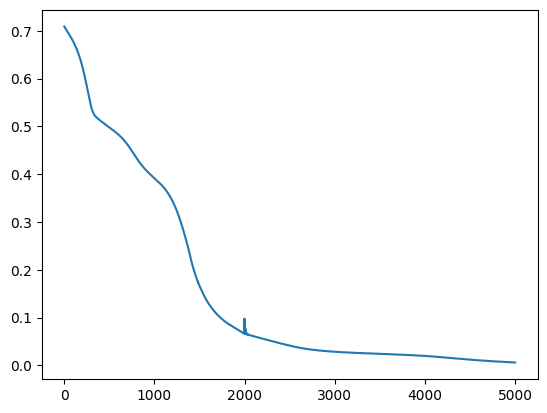

In [42]:
rnn = LSTM(n_joints,n_hidden,n_categories,n_layer, seq_len)
rnn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn.parameters(),lr=learning_rate)

all_losses = []
for iter in tqdm( range(1, n_iters + 1) ):
     
    data, target = X_train_tensor.to(device), y_train_tensor.to(device)
    rnn.zero_grad()
    output = rnn(data)
    loss = criterion(output, target.long())
    loss.backward()
    optimizer.step()
    current_loss  = loss.item()
        
    all_losses.append(current_loss)
    if iter % print_every == 0:
        print(f'{iter} {current_loss}') 

plt.plot(all_losses)


rnn.eval()
with torch.no_grad():
    y_pred=rnn(X_test_tensor)
    y_pred=y_pred.argmax(dim=1)
    acc=(y_pred==y_test_tensor).float().mean()
    print('acc=', acc.item())

In [45]:
# k-fold cross validation
k=5

seed=10
np.random.seed(seed)
torch.manual_seed(seed)
indices=np.arange(X.shape[0])
np.random.shuffle(indices)
fold_size=int(X.shape[0]/k)

accs=[]
for i in range(k):
    test_indices=indices[i*fold_size:(i+1)*fold_size]
    train_indices=indices[~np.isin(indices, test_indices)]
    X_train=X[train_indices]
    y_train=y[train_indices]
    X_test=X[test_indices]
    y_test=y[test_indices]
    print(f"Fold {i+1}:")
    print(f"Train: {X_train.shape}, {y_train.shape}")
    print(f"Test: {X_test.shape}, {y_test.shape}")
    print('------------------------')

    X_train_tensor=torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_tensor=torch.tensor(y_train, dtype=torch.float32).to(device)
    X_test_tensor=torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_tensor=torch.tensor(y_test, dtype=torch.float32).to(device)
    
    
    rnn = LSTM(n_joints,n_hidden,n_categories,n_layer, seq_len)
    rnn.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(rnn.parameters(),lr=learning_rate)

    all_losses = []
    for iter in tqdm( range(1, n_iters + 1) ):
        
        data, target = X_train_tensor.to(device), y_train_tensor.to(device)
        rnn.zero_grad()
        output = rnn(data)
        loss = criterion(output, target.long())
        loss.backward()
        optimizer.step()
        current_loss  = loss.item()
            
        all_losses.append(current_loss)  
    rnn.eval()
    with torch.no_grad():
        y_pred=rnn(X_test_tensor)
        y_pred=y_pred.argmax(dim=1)
        acc=(y_pred==y_test_tensor).float().mean()
        print('acc=', acc.item())
        accs.append(acc.item())

print('Mean accuracy:', np.mean(accs))

Fold 1:
Train: (154, 10, 50), (154,)
Test: (38, 10, 50), (38,)
------------------------


100%|██████████| 5000/5000 [00:41<00:00, 121.63it/s]


acc= 0.8157894611358643
Fold 2:
Train: (154, 10, 50), (154,)
Test: (38, 10, 50), (38,)
------------------------


100%|██████████| 5000/5000 [00:40<00:00, 123.80it/s]


acc= 0.7368420958518982
Fold 3:
Train: (154, 10, 50), (154,)
Test: (38, 10, 50), (38,)
------------------------


...

acc= 0.7368420958518982
Fold 4:
Train: (154, 10, 50), (154,)
Test: (38, 10, 50), (38,)
------------------------


100%|██████████| 5000/5000 [00:41<00:00, 121.70it/s]


acc= 0.7631579041481018
Fold 5:
Train: (154, 10, 50), (154,)
Test: (38, 10, 50), (38,)
------------------------


100%|██████████| 5000/5000 [00:43<00:00, 115.56it/s]

acc= 0.6842105388641357
Mean accuracy: 0.7473684191703797
